In [1]:
# import libraries
import math
import copy
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display # for printing things in LaTex

In [2]:
# ------------------------------------------------------------
# 1. Define symbolic node coordinates (FULL NODE MODEL)
# ------------------------------------------------------------

# Unit 0 nodes
y0B, z0B = sp.symbols('y0B z0B', real=True)  # bottom
y0L, z0L = sp.symbols('y0L z0L', real=True)  # left
y0R, z0R = sp.symbols('y0R z0R', real=True)  # right
y0T, z0T = sp.symbols('y0T z0T', real=True)  # top

# Unit 1 nodes
y1B, z1B = sp.symbols('y1B z1B', real=True)  # bottom
y1L, z1L = sp.symbols('y1L z1L', real=True)  # left
y1R, z1R = sp.symbols('y1R z1R', real=True)  # right
y1T, z1T = sp.symbols('y1T z1T', real=True)  # top

# Node list IMPORTANT: pay attention to order
nodes = [
    sp.Matrix([y0B, z0B]),  # 0 = p0B
    sp.Matrix([y0L, z0L]),  # 1 = p0L
    sp.Matrix([y0R, z0R]),  # 2 = p0R
    sp.Matrix([y0T, z0T]),  # 3 = p0T
    sp.Matrix([y1B, z1B]),  # 4 = p1B
    sp.Matrix([y1L, z1L]),  # 5 = p1L
    sp.Matrix([y1R, z1R]),  # 6 = p1R
    sp.Matrix([y1T, z1T]),  # 7 = p1T
]

# TODO: plot nodes

# good to store this info; may use later
N = len(nodes)
dim = 2

print("total nodes:", N)
print("dimensions:", dim)

total nodes: 8
dimensions: 2


In [3]:
# ------------------------------------------------------------
# 2. Define displacement vector u
# ------------------------------------------------------------

u_symbols = []
for i in range(N):
    uiy, uiz = sp.symbols(f'u{i}y u{i}z', real=True)
    u_symbols.extend([uiy, uiz])

u = sp.Matrix(u_symbols)   # shape = (2N, 1)
print("u shape:", u.shape)  # should be (16,1)

u shape: (16, 1)


In [4]:
# ------------------------------------------------------------
# 3. Define shape bonds (constraints)
# ------------------------------------------------------------

shape_bonds = [
    # UNIT 0
    (0, 1),  # bottom -> left
    (1, 3),  # left -> top
    (3, 2),  # top -> right
    (2, 0),  # right -> bottom

    # UNIT 1
    (4, 5),  # bottom -> left
    (5, 7),  # left -> top
    (7, 6),  # top -> right
    (6, 4),  # right -> bottom

    # vertical spine
    (0, 3),  # unit 0: bottom -> top
    (4, 7),  # unit 1: bottom -> top
]

print("number of constraints:", len(shape_bonds))

number of constraints: 10


In [5]:
# ------------------------------------------------------------
# 4. Build configuration vector q from node-coordinate symbols
# ------------------------------------------------------------

q = sp.Matrix([
    y0B, z0B,
    y0L, z0L,
    y0R, z0R,
    y0T, z0T,
    y1B, z1B,
    y1L, z1L,
    y1R, z1R,
    y1T, z1T,
])

print("q shape:", q.shape)   # should be (16, 1)

q shape: (16, 1)


In [6]:
# ------------------------------------------------------------
# 5. Define scalar constraint functions l_k(q)
# ------------------------------------------------------------

def bond_length_constraint(i, j, nodes):
    '''
    Returns the scalar bond-length constraint
        l_ij(q) = ||x_j - x_i||
    where x_i and x_j are node position vectors.
    '''
    xi = nodes[i]
    xj = nodes[j]
    d = xj - xi
    return sp.sqrt((d.T * d)[0])


def fix_y_constraint(i, q):
    '''
    Returns the scalar fixed constraint
        l(q) = y_i
    meaning node i cannot move in y.
    '''
    return q[2*i]


def fix_z_constraint(i, q):
    '''
    Returns the scalar fixed constraint
        l(q) = z_i
    meaning node i cannot move in z.
    '''
    return q[2*i + 1]

In [7]:
# ------------------------------------------------------------
# 6. Build l(q) = vector of active constraints
# ------------------------------------------------------------

l_entries = []

# ---- bond-length constraints ----
for (i, j) in shape_bonds:
    l_entries.append(bond_length_constraint(i, j, nodes))

# ---- support / grounding constraints ----
# same support choice as the cleaned-up C-matrix version:
#   node 0 fixed in y and z
#   node 3 fixed in y
anchor_node = 0
anti_rotation_node = 3

l_entries.append(fix_y_constraint(anchor_node, q))         # y0B
l_entries.append(fix_z_constraint(anchor_node, q))         # z0B
l_entries.append(fix_y_constraint(anti_rotation_node, q))  # y0T

# ---- guide constraint for top-bottom pin ----
# node 4 constrained to vertical motion only -> fix y
top_bottom_pin = 4
l_entries.append(fix_y_constraint(top_bottom_pin, q))      # y1B

# stack all scalar constraints into one column vector
l_q = sp.Matrix(l_entries)

print("l(q) shape:", l_q.shape)   # should be (14, 1)
display(l_q)

l(q) shape: (14, 1)


Matrix([
[sqrt((-y0B + y0L)**2 + (-z0B + z0L)**2)],
[sqrt((-y0L + y0T)**2 + (-z0L + z0T)**2)],
[  sqrt((y0R - y0T)**2 + (z0R - z0T)**2)],
[  sqrt((y0B - y0R)**2 + (z0B - z0R)**2)],
[sqrt((-y1B + y1L)**2 + (-z1B + z1L)**2)],
[sqrt((-y1L + y1T)**2 + (-z1L + z1T)**2)],
[  sqrt((y1R - y1T)**2 + (z1R - z1T)**2)],
[  sqrt((y1B - y1R)**2 + (z1B - z1R)**2)],
[sqrt((-y0B + y0T)**2 + (-z0B + z0T)**2)],
[sqrt((-y1B + y1T)**2 + (-z1B + z1T)**2)],
[                                    y0B],
[                                    z0B],
[                                    y0T],
[                                    y1B]])

In [8]:
# -----------------------------------------------------------------------------
# 6b. Get the Hamiltonian (symbolically)
# -----------------------------------------------------------------------------
#
# define a baseline for the Hamiltonian (node locations)
# MIND: the Hamiltonian is calculated for specific configurations
# (i.e. change this to analyze different geometries)
#
q0_ref = {
    y0B: 0,   z0B: 0,
    y0L: -8,  z0L: 10,
    y0R:  8,  z0R: 10,
    y0T: 0,   z0T: 20,

    y1B: 0,   z1B: 10,
    y1L: -8,  z1L: 20,
    y1R:  8,  z1R: 20,
    y1T: 0,   z1T: 30,
}

# q0 = reference node-coordinate vector
q0 = q.subs(q0_ref)

# u = displacement from reference configuration
u = q - q0

# l(q0) and delta l
l_q0 = l_q.subs(q0_ref)
delta_l = l_q - l_q0

# Number of geometric measures / constraints in l(q)
m = len(l_q)

# Stiffness for each term in l(q)
k_syms = sp.symbols(f'k0:{m}', positive=True, real=True)
k_vec = sp.Matrix(k_syms)

# Preferred values for the full elastic energy
# TODO: understand this: it's in the energy formula; not really sure about the physical interpretation yet
lstar_syms = sp.symbols(f'lstar0:{m}', real=True)
lstar = sp.Matrix(lstar_syms)

# Elastic energy:
# E[l(q)] = 1/2 sum_a k_a (l_a(q) - l*_a)^2
E_elastic = sp.Rational(1, 2) * sum(
    k_vec[a] * (l_q[a] - lstar[a])**2
    for a in range(m)
)

# OPTIONAL: full-Hamiltonian terms from the paper
lam = sp.symbols('lambda', nonnegative=True, real=True)

f_syms = sp.symbols(f'f0:{len(q)}', real=True)   # generalized external forces
t_syms = sp.symbols(f't0:{m}', real=True)        # prestress / tension-like terms

f_vec = sp.Matrix(f_syms)
t_vec = sp.Matrix(t_syms)

# Regularization + loading terms
E_reg = sp.Rational(1, 2) * lam * u.dot(u)
W_force = f_vec.dot(u)
W_tension = t_vec.dot(delta_l)

# Full symbolic Hamiltonian
Hamiltonian = sp.simplify(E_elastic + E_reg - W_force - W_tension)

print("Full symbolic Hamiltonian:")
display(Hamiltonian)

# -----------------------------------------------------------------------------
# Simple Hamiltonian:
# - no external loads        (f = 0)
# - no prestress             (t = 0)
# - no regularization term   (lambda = 0)
# - preferred values set to the reference configuration: l* = l(q0)
# -----------------------------------------------------------------------------

Hamiltonian_simple = sp.simplify(
    sp.Rational(1, 2) * sum(
        k_vec[a] * (l_q[a] - l_q0[a])**2
        for a in range(m)
    )
)

print("Simple Hamiltonian:")
display(Hamiltonian_simple)

Full symbolic Hamiltonian:


-f0*y0B - f1*z0B - f10*(y1L + 8) - f11*(z1L - 20) - f12*(y1R - 8) - f13*(z1R - 20) - f14*y1T - f15*(z1T - 30) - f2*(y0L + 8) - f3*(z0L - 10) - f4*(y0R - 8) - f5*(z0R - 10) - f6*y0T - f7*(z0T - 20) - f8*y1B - f9*(z1B - 10) + k0*(lstar0 - sqrt((y0B - y0L)**2 + (z0B - z0L)**2))**2/2 + k1*(lstar1 - sqrt((y0L - y0T)**2 + (z0L - z0T)**2))**2/2 + k10*(lstar10 - y0B)**2/2 + k11*(lstar11 - z0B)**2/2 + k12*(lstar12 - y0T)**2/2 + k13*(lstar13 - y1B)**2/2 + k2*(lstar2 - sqrt((y0R - y0T)**2 + (z0R - z0T)**2))**2/2 + k3*(lstar3 - sqrt((y0B - y0R)**2 + (z0B - z0R)**2))**2/2 + k4*(lstar4 - sqrt((y1B - y1L)**2 + (z1B - z1L)**2))**2/2 + k5*(lstar5 - sqrt((y1L - y1T)**2 + (z1L - z1T)**2))**2/2 + k6*(lstar6 - sqrt((y1R - y1T)**2 + (z1R - z1T)**2))**2/2 + k7*(lstar7 - sqrt((y1B - y1R)**2 + (z1B - z1R)**2))**2/2 + k8*(lstar8 - sqrt((y0B - y0T)**2 + (z0B - z0T)**2))**2/2 + k9*(lstar9 - sqrt((y1B - y1T)**2 + (z1B - z1T)**2))**2/2 + lambda*(y0B**2 + y0T**2 + y1B**2 + y1T**2 + z0B**2 + (y0L + 8)**2 + (y0R - 8)*

Simple Hamiltonian:


k0*(sqrt((y0B - y0L)**2 + (z0B - z0L)**2) - 2*sqrt(41))**2/2 + k1*(sqrt((y0L - y0T)**2 + (z0L - z0T)**2) - 2*sqrt(41))**2/2 + k10*y0B**2/2 + k11*z0B**2/2 + k12*y0T**2/2 + k13*y1B**2/2 + k2*(sqrt((y0R - y0T)**2 + (z0R - z0T)**2) - 2*sqrt(41))**2/2 + k3*(sqrt((y0B - y0R)**2 + (z0B - z0R)**2) - 2*sqrt(41))**2/2 + k4*(sqrt((y1B - y1L)**2 + (z1B - z1L)**2) - 2*sqrt(41))**2/2 + k5*(sqrt((y1L - y1T)**2 + (z1L - z1T)**2) - 2*sqrt(41))**2/2 + k6*(sqrt((y1R - y1T)**2 + (z1R - z1T)**2) - 2*sqrt(41))**2/2 + k7*(sqrt((y1B - y1R)**2 + (z1B - z1R)**2) - 2*sqrt(41))**2/2 + k8*(sqrt((y0B - y0T)**2 + (z0B - z0T)**2) - 20)**2/2 + k9*(sqrt((y1B - y1T)**2 + (z1B - z1T)**2) - 20)**2/2

In [9]:
# -----------------------------------------------------------------------------
# 7. Build compatability matrix CDifferentiate l_q with respect to q to get C
# -----------------------------------------------------------------------------

C = l_q.jacobian(q)

print("C shape:", C.shape)   # should be (14, 16)
display(C)

C shape: (14, 16)


Matrix([
[(y0B - y0L)/sqrt((-y0B + y0L)**2 + (-z0B + z0L)**2), (z0B - z0L)/sqrt((-y0B + y0L)**2 + (-z0B + z0L)**2), (-y0B + y0L)/sqrt((-y0B + y0L)**2 + (-z0B + z0L)**2), (-z0B + z0L)/sqrt((-y0B + y0L)**2 + (-z0B + z0L)**2),                                                  0,                                                  0,                                                    0,                                                    0,                                                   0,                                                   0,                                                    0,                                                    0,                                                  0,                                                  0,                                                    0,                                                    0],
[                                                  0,                                                   0,  (y0L - y0T)/sqrt((-y0L + y0T)

In [10]:
# ------------------------------------------------------------
# 8. Stiffness matrix K (symbolic)
# ------------------------------------------------------------
# one stiffness per active constraint in l(q)

nc = len(l_q)   # total number of active constraints

k_constraints = sp.symbols(f'k0:{nc}', positive=True, real=True)
K = sp.diag(*k_constraints)

print("number of active constraints:", nc)
print("K shape:", K.shape)
print("K matrix: ")
display(K)


# ------------------------------------------------------------
# 10. Symbolic Hessian (linearized stiffness matrix)
# ------------------------------------------------------------
# H = C^T K C

Hess_sym = C.T * K * C

print("Symbolic Hessian shape:", Hess_sym.shape)
# display(Hess_sym)   # careful: this can get very large


# ------------------------------------------------------------
# 11. Symbolic Hamiltonian / quadratic energy in u
# ------------------------------------------------------------
# H(u) = 1/2 u^T Hess_sym u

H_sym = sp.Rational(1, 2) * (u.T * Hess_sym * u)[0]

print("Symbolic Hamiltonian:")
display(H_sym)

print("Symbolic Hessian:")
display(Hess_sym)

number of active constraints: 14
K shape: (14, 14)
K matrix: 


Matrix([
[k0,  0,  0,  0,  0,  0,  0,  0,  0,  0,   0,   0,   0,   0],
[ 0, k1,  0,  0,  0,  0,  0,  0,  0,  0,   0,   0,   0,   0],
[ 0,  0, k2,  0,  0,  0,  0,  0,  0,  0,   0,   0,   0,   0],
[ 0,  0,  0, k3,  0,  0,  0,  0,  0,  0,   0,   0,   0,   0],
[ 0,  0,  0,  0, k4,  0,  0,  0,  0,  0,   0,   0,   0,   0],
[ 0,  0,  0,  0,  0, k5,  0,  0,  0,  0,   0,   0,   0,   0],
[ 0,  0,  0,  0,  0,  0, k6,  0,  0,  0,   0,   0,   0,   0],
[ 0,  0,  0,  0,  0,  0,  0, k7,  0,  0,   0,   0,   0,   0],
[ 0,  0,  0,  0,  0,  0,  0,  0, k8,  0,   0,   0,   0,   0],
[ 0,  0,  0,  0,  0,  0,  0,  0,  0, k9,   0,   0,   0,   0],
[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0, k10,   0,   0,   0],
[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,   0, k11,   0,   0],
[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,   0,   0, k12,   0],
[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,   0,   0,   0, k13]])

Symbolic Hessian shape: (16, 16)
Symbolic Hamiltonian:


y0B*(k0*(-y0B + y0L)*(y0B - y0L)*(y0L + 8)/((-y0B + y0L)**2 + (-z0B + z0L)**2) + k0*(y0B - y0L)*(-z0B + z0L)*(z0L - 10)/((-y0B + y0L)**2 + (-z0B + z0L)**2) + k3*(-y0B + y0R)*(y0B - y0R)*(y0R - 8)/((y0B - y0R)**2 + (z0B - z0R)**2) + k3*(y0B - y0R)*(-z0B + z0R)*(z0R - 10)/((y0B - y0R)**2 + (z0B - z0R)**2) + k8*y0T*(-y0B + y0T)*(y0B - y0T)/((-y0B + y0T)**2 + (-z0B + z0T)**2) + k8*(y0B - y0T)*(-z0B + z0T)*(z0T - 20)/((-y0B + y0T)**2 + (-z0B + z0T)**2) + y0B*(k0*(y0B - y0L)**2/((-y0B + y0L)**2 + (-z0B + z0L)**2) + k10 + k3*(y0B - y0R)**2/((y0B - y0R)**2 + (z0B - z0R)**2) + k8*(y0B - y0T)**2/((-y0B + y0T)**2 + (-z0B + z0T)**2)) + z0B*(k0*(y0B - y0L)*(z0B - z0L)/((-y0B + y0L)**2 + (-z0B + z0L)**2) + k3*(y0B - y0R)*(z0B - z0R)/((y0B - y0R)**2 + (z0B - z0R)**2) + k8*(y0B - y0T)*(z0B - z0T)/((-y0B + y0T)**2 + (-z0B + z0T)**2)))/2 + y0T*(k1*(-y0L + y0T)*(y0L + 8)*(y0L - y0T)/((-y0L + y0T)**2 + (-z0L + z0T)**2) + k1*(-y0L + y0T)*(z0L - 10)*(z0L - z0T)/((-y0L + y0T)**2 + (-z0L + z0T)**2) + k2*(-y0R

Symbolic Hessian:


Matrix([
[                     k0*(y0B - y0L)**2/((-y0B + y0L)**2 + (-z0B + z0L)**2) + k10 + k3*(y0B - y0R)**2/((y0B - y0R)**2 + (z0B - z0R)**2) + k8*(y0B - y0T)**2/((-y0B + y0T)**2 + (-z0B + z0T)**2), k0*(y0B - y0L)*(z0B - z0L)/((-y0B + y0L)**2 + (-z0B + z0L)**2) + k3*(y0B - y0R)*(z0B - z0R)/((y0B - y0R)**2 + (z0B - z0R)**2) + k8*(y0B - y0T)*(z0B - z0T)/((-y0B + y0T)**2 + (-z0B + z0T)**2),                                                                   k0*(-y0B + y0L)*(y0B - y0L)/((-y0B + y0L)**2 + (-z0B + z0L)**2),                                                                   k0*(y0B - y0L)*(-z0B + z0L)/((-y0B + y0L)**2 + (-z0B + z0L)**2),                                                                 k3*(-y0B + y0R)*(y0B - y0R)/((y0B - y0R)**2 + (z0B - z0R)**2),                                                                 k3*(y0B - y0R)*(-z0B + z0R)/((y0B - y0R)**2 + (z0B - z0R)**2),                                                                                           

In [11]:
# ------------------------------------------------------------
# Introduce real system (2D 2unit RAMMs Chain)
# ------------------------------------------------------------
# 2unit chain sample:
# bottom of unit 0 is at 0,0
# bottom of unit 1 is at 10,0 (half dist unit 0)
conf_1 = { # unit 1 is "floating"–should result in postive #LZM
    y0B: 0,   z0B: 0,
    y0L: -8,  z0L: 10,
    y0R:  8,  z0R: 10,
    y0T: 0,   z0T: 20,

    y1B: 0,   z1B: 10,
    y1L: -8,  z1L: 20,
    y1R:  8,  z1R: 20,
    y1T: 0,   z1T: 30,
}

C_num = C.subs(conf_1)
print("Rank(C):", C_num.rank())

Rank(C): 14


In [12]:
import math
import copy

# -------------------------------------------------------
# 1. Helper: read/write one unit's nodes
# -------------------------------------------------------
def get_unit_points(conf, unit):
    return {
        "B": (conf[globals()[f"y{unit}B"]], conf[globals()[f"z{unit}B"]]),
        "L": (conf[globals()[f"y{unit}L"]], conf[globals()[f"z{unit}L"]]),
        "R": (conf[globals()[f"y{unit}R"]], conf[globals()[f"z{unit}R"]]),
        "T": (conf[globals()[f"y{unit}T"]], conf[globals()[f"z{unit}T"]]),
    }

def set_unit_points(conf, unit, pts):
    conf[globals()[f"y{unit}B"]] = pts["B"][0]
    conf[globals()[f"z{unit}B"]] = pts["B"][1]

    conf[globals()[f"y{unit}L"]] = pts["L"][0]
    conf[globals()[f"z{unit}L"]] = pts["L"][1]

    conf[globals()[f"y{unit}R"]] = pts["R"][0]
    conf[globals()[f"z{unit}R"]] = pts["R"][1]

    conf[globals()[f"y{unit}T"]] = pts["T"][0]
    conf[globals()[f"z{unit}T"]] = pts["T"][1]

# -------------------------------------------------------
# 2. Basic geometry helpers
# -------------------------------------------------------
def unit_center(pts):
    yB, zB = pts["B"]
    yT, zT = pts["T"]
    return ((yB + yT) / 2.0, (zB + zT) / 2.0)

def rotate_point(y, z, yc, zc, theta_deg):
    theta = math.radians(theta_deg)
    dy = y - yc
    dz = z - zc

    y_new = yc + dy * math.cos(theta) - dz * math.sin(theta)
    z_new = zc + dy * math.sin(theta) + dz * math.cos(theta)
    return (y_new, z_new)

def translate_points(pts, dy=0.0, dz=0.0):
    return {
        name: (y + dy, z + dz)
        for name, (y, z) in pts.items()
    }

def rotate_points(pts, theta_deg, center):
    yc, zc = center
    return {
        name: rotate_point(y, z, yc, zc, theta_deg)
        for name, (y, z) in pts.items()
    }

# -------------------------------------------------------
# 3. Main helper: transform a unit in a config
# -------------------------------------------------------
def transform_unit(
    conf,
    unit=1,
    rotate_deg=0.0,
    move_y=0.0,
    move_z=0.0,
    rotation_center=("node", "B"),
):
    """
    Return a NEW config with a rigid transform applied to one unit.

    Default behavior:
    - rotate about the unit's bottom pin ("B")
    - then translate by (move_y, move_z)

    Parameters
    ----------
    conf : dict
        Original configuration dictionary with symbolic keys.
    unit : int
        Which unit to transform.
    rotate_deg : float
        Rotation angle in degrees.
    move_y : float
        Translation in y after rotation.
    move_z : float
        Translation in z after rotation.
    rotation_center : str or tuple
        - ("node", "B")  -> default, rotate about bottom pin
        - "unit_center"  -> rotate about unit center
        - "origin"       -> rotate about (0,0)
        - ("node", "L")  -> rotate about a specific node
        - (yc, zc)       -> rotate about a custom point
    """
    conf_new = copy.deepcopy(conf)
    pts = get_unit_points(conf_new, unit)

    if rotation_center == "unit_center":
        center = unit_center(pts)
    elif rotation_center == "origin":
        center = (0.0, 0.0)
    elif isinstance(rotation_center, tuple) and len(rotation_center) == 2 and rotation_center[0] == "node":
        node_name = rotation_center[1]
        center = pts[node_name]
    elif isinstance(rotation_center, tuple) and len(rotation_center) == 2:
        center = rotation_center
    else:
        raise ValueError(
            "rotation_center must be one of: "
            "('node','B'), 'unit_center', 'origin', ('node','L'), or (yc, zc)"
        )

    pts_new = rotate_points(pts, rotate_deg, center=center)
    pts_new = translate_points(pts_new, dy=move_y, dz=move_z)

    set_unit_points(conf_new, unit, pts_new)
    return conf_new

In [13]:
def get_node(geom, y_key, z_key):
    return (geom[y_key], geom[z_key])

def plot_unit(ax, geom, unit_keys, unit_name="0", show_labels=True):
    B = get_node(geom, unit_keys["B"][0], unit_keys["B"][1])
    L = get_node(geom, unit_keys["L"][0], unit_keys["L"][1])
    T = get_node(geom, unit_keys["T"][0], unit_keys["T"][1])
    R = get_node(geom, unit_keys["R"][0], unit_keys["R"][1])

    edges = [(B, L), (L, T), (T, R), (R, B)]
    for p1, p2 in edges:
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], linewidth=2)

    nodes = {"B": B, "L": L, "R": R, "T": T}
    for name, (y, z) in nodes.items():
        ax.plot(y, z, "o", markersize=8)
        if show_labels:
            ax.text(y + 0.4, z + 0.4, f"{unit_name}{name}", fontsize=10)

def plot_geometry(geom, title="RAMM Geometry"):
    fig, ax = plt.subplots(figsize=(6, 8))

    unit0_keys = {
        "B": (y0B, z0B),
        "L": (y0L, z0L),
        "R": (y0R, z0R),
        "T": (y0T, z0T),
    }

    unit1_keys = {
        "B": (y1B, z1B),
        "L": (y1L, z1L),
        "R": (y1R, z1R),
        "T": (y1T, z1T),
    }

    plot_unit(ax, geom, unit0_keys, unit_name="0")
    plot_unit(ax, geom, unit1_keys, unit_name="1")

    ax.set_xlabel("y")
    ax.set_ylabel("z")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.grid(True)
    plt.show()


In [14]:
conf_rot37 = transform_unit(conf_1, unit=1, rotate_deg=36)

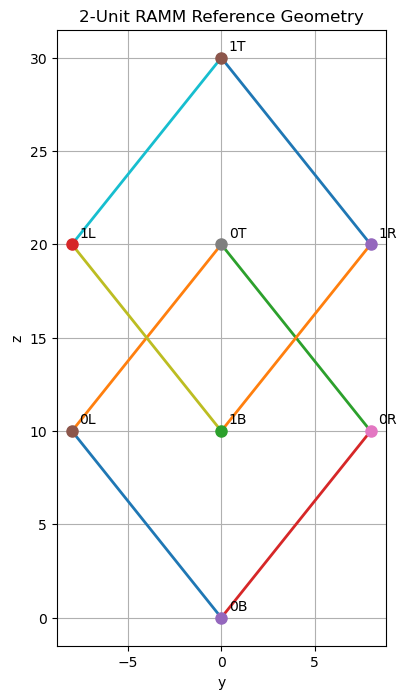

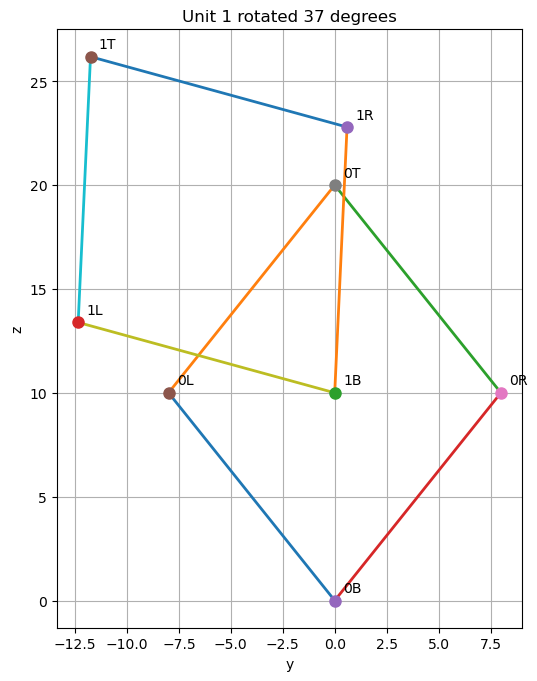

In [15]:
plot_geometry(conf_1, title="2-Unit RAMM Reference Geometry")
plot_geometry(conf_rot37, title="Unit 1 rotated 37 degrees")

In [16]:
# Get max angle config
# -------------------------------------------------------
# Basic geometry helpers
# -------------------------------------------------------
def dist(p, q):
    return math.hypot(p[0] - q[0], p[1] - q[1])

def cross2d(a, b):
    return a[0]*b[1] - a[1]*b[0]

def point_on_segment(p, a, b, tol=1e-9):
    """
    True if point p lies on segment a->b.
    """
    ap = (p[0] - a[0], p[1] - a[1])
    ab = (b[0] - a[0], b[1] - a[1])

    if abs(cross2d(ap, ab)) > tol:
        return False

    dot = ap[0]*ab[0] + ap[1]*ab[1]
    if dot < -tol:
        return False

    ab_len_sq = ab[0]*ab[0] + ab[1]*ab[1]
    if dot > ab_len_sq + tol:
        return False

    return True

def get_node_from_conf(conf, unit, node):
    return (
        conf[globals()[f"y{unit}{node}"]],
        conf[globals()[f"z{unit}{node}"]],
    )

In [17]:
def signed_area2(a, b, p):
    """
    2D signed area / cross product:
    > 0 : p is to the left of directed line a->b
    = 0 : collinear
    < 0 : p is to the right of directed line a->b
    """
    return (b[0] - a[0])*(p[1] - a[1]) - (b[1] - a[1])*(p[0] - a[0])


def is_valid_rotation_with_vertical_slide(conf_rot, tol=1e-6, verbose=False):
    """
    Rules interpreted geometrically:

    1. 1B stays on its vertical track
       -> handled by transform_unit(... move_y=0)

    2. 1R cannot be left of 0T
       -> y1R >= y0T

    3. 1L cannot be below 0L
       -> z1L >= z0L

    4. link 1B->1R must NOT have passed 0T
       -> 0T must stay strictly to the left of directed segment 1B->1R

    5. link 1B->1L must NOT have passed 0L
       -> 0L must stay strictly to the left of directed segment 1B->1L
    """
    p0T = get_node_from_conf(conf_rot, 0, "T")
    p0L = get_node_from_conf(conf_rot, 0, "L")
    p1B = get_node_from_conf(conf_rot, 1, "B")
    p1L = get_node_from_conf(conf_rot, 1, "L")
    p1R = get_node_from_conf(conf_rot, 1, "R")

    # side tests: positive means "has not passed yet"
    side_BR_0T = signed_area2(p1B, p1R, p0T)
    side_BL_0L = signed_area2(p1B, p1L, p0L)

    checks = {
        "1R_not_left_of_0T": p1R[0] >= p0T[0] - tol,
        "1L_not_below_0L":   p1L[1] >= p0L[1] - tol,

        # STRICTLY positive: do not allow touching / sitting exactly on boundary
        "0T_left_of_1B1R": side_BR_0T > tol,
        "0L_left_of_1B1L": side_BL_0L > tol,
    }

    if verbose:
        print("Validity checks:")
        for k, v in checks.items():
            print(f"  {k}: {v}")
        print(f"  side_BR_0T = {side_BR_0T}")
        print(f"  side_BL_0L = {side_BL_0L}")

    return all(checks.values())

In [18]:
def find_max_rotation_with_vertical_slide(
    conf_base,
    unit=1,
    angle_min=0.0,
    angle_max=90.0,
    z_shift_min=-20.0,
    z_shift_max=20.0,
    angle_step=0.1,
    z_step=0.1,
    refine=True,
    refine_angle_step=1e-3,
    refine_z_step=1e-3,
    tol=1e-9,
):
    """
    Search over:
      - rotation angle about 1B
      - vertical translation of unit 1 after rotation

    Constraints:
      - 1B may move only vertically
      - 1B may NOT move in y

    Objective:
      - maximize angle first
      - among same-angle valid configs, choose one with 1R closest to 0T
    """
    best_angle = None
    best_conf = None
    best_info = None

    angle = angle_min
    while angle <= angle_max + 0.5*angle_step:
        z_shift = z_shift_min
        best_at_this_angle = None

        while z_shift <= z_shift_max + 0.5*z_step:
            conf_test = transform_unit(
                conf_base,
                unit=unit,
                rotate_deg=angle,
                move_y=0.0,          # 1B stays on vertical track
                move_z=z_shift,      # allow sliding in z
                rotation_center=("node", "B"),
            )

            if is_valid_rotation_with_vertical_slide(conf_test, tol=tol):
                p0T = get_node_from_conf(conf_test, 0, "T")
                p1R = get_node_from_conf(conf_test, 1, "R")
                p0L = get_node_from_conf(conf_test, 0, "L")
                p1L = get_node_from_conf(conf_test, 1, "L")
                p1B = get_node_from_conf(conf_test, 1, "B")

                info = {
                    "angle": angle,
                    "z_shift": z_shift,
                    "distance_1R_to_0T": dist(p1R, p0T),
                    "distance_1L_to_0L": dist(p1L, p0L),
                    "p0T": p0T,
                    "p1R": p1R,
                    "p0L": p0L,
                    "p1L": p1L,
                    "p1B": p1B,
                }

                # At a fixed angle, prefer smaller distance from 1R to 0T
                if best_at_this_angle is None or info["distance_1R_to_0T"] < best_at_this_angle["info"]["distance_1R_to_0T"]:
                    best_at_this_angle = {
                        "conf": conf_test,
                        "info": info,
                    }

            z_shift += z_step

        # If this angle has any valid vertical placement, keep it
        if best_at_this_angle is not None:
            best_angle = angle
            best_conf = best_at_this_angle["conf"]
            best_info = best_at_this_angle["info"]

        angle += angle_step

    if best_angle is None:
        raise ValueError("No valid (angle, z_shift) pair found.")

    # Optional local refinement around the best coarse solution
    if refine:
        a0 = best_info["angle"]
        z0 = best_info["z_shift"]

        angle_start = max(angle_min, a0 - angle_step)
        angle_stop  = min(angle_max, a0 + angle_step)
        z_start     = max(z_shift_min, z0 - z_step)
        z_stop      = min(z_shift_max, z0 + z_step)

        angle = angle_start
        while angle <= angle_stop + 0.5*refine_angle_step:
            z_shift = z_start
            while z_shift <= z_stop + 0.5*refine_z_step:
                conf_test = transform_unit(
                    conf_base,
                    unit=unit,
                    rotate_deg=angle,
                    move_y=0.0,
                    move_z=z_shift,
                    rotation_center=("node", "B"),
                )

                if is_valid_rotation_with_vertical_slide(conf_test, tol=tol):
                    p0T = get_node_from_conf(conf_test, 0, "T")
                    p1R = get_node_from_conf(conf_test, 1, "R")
                    p0L = get_node_from_conf(conf_test, 0, "L")
                    p1L = get_node_from_conf(conf_test, 1, "L")
                    p1B = get_node_from_conf(conf_test, 1, "B")

                    info = {
                        "angle": angle,
                        "z_shift": z_shift,
                        "distance_1R_to_0T": dist(p1R, p0T),
                        "distance_1L_to_0L": dist(p1L, p0L),
                        "p0T": p0T,
                        "p1R": p1R,
                        "p0L": p0L,
                        "p1L": p1L,
                        "p1B": p1B,
                    }

                    better_angle = angle > best_info["angle"] + tol
                    same_angle_better_fit = abs(angle - best_info["angle"]) <= tol and info["distance_1R_to_0T"] < best_info["distance_1R_to_0T"]

                    if better_angle or same_angle_better_fit:
                        best_angle = angle
                        best_conf = conf_test
                        best_info = info

                z_shift += refine_z_step
            angle += refine_angle_step

    return best_angle, best_conf, best_info

Best angle: 38.65899999999981
Best z shift: -1.7999999999999279
Distance 1R -> 0T: 1.006248489808131


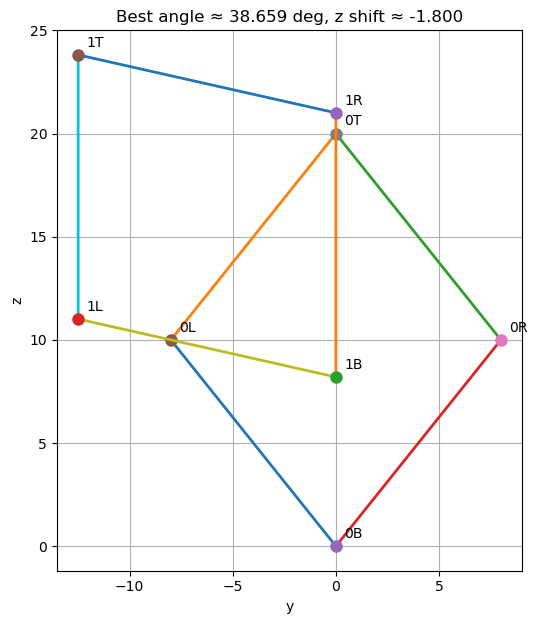

In [19]:
best_angle, best_conf, best_info = find_max_rotation_with_vertical_slide(
    conf_1,
    unit=1,
    angle_min=0.0,
    angle_max=90.0,
    z_shift_min=-15.0,
    z_shift_max=15.0,
    angle_step=0.05,
    z_step=0.05,
    refine=True,
    refine_angle_step=1e-3,
    refine_z_step=1e-3,
    tol=1e-5,
)

print("Best angle:", best_angle)
print("Best z shift:", best_info["z_shift"])
print("Distance 1R -> 0T:", best_info["distance_1R_to_0T"])

plot_geometry(best_conf, title=f"Best angle ≈ {best_angle:.3f} deg, z shift ≈ {best_info['z_shift']:.3f}")

In [45]:
# potential faster way...
def rotate_about_bottom_pin_only(conf, unit=1, rotate_deg=0.0):
    """
    Rotate unit about its own bottom pin only.
    No translation applied.
    """
    return transform_unit(
        conf,
        unit=unit,
        rotate_deg=rotate_deg,
        move_y=0.0,
        move_z=0.0,
        rotation_center=("node", "B"),
    )

In [46]:
def best_vertical_shift_from_1L(conf_rot, tol=1e-9):
    """
    Choose the vertical shift that places 1L exactly at the same height as 0L:
        z1L == z0L

    This is the lowest allowed placement if the rule is:
        1L cannot be below 0L
    """
    p0L = get_node_from_conf(conf_rot, 0, "L")
    p1L = get_node_from_conf(conf_rot, 1, "L")
    return p0L[1] - p1L[1]

In [47]:
def apply_vertical_shift(conf, unit=1, z_shift=0.0):
    """
    Move a unit only in z.
    """
    return transform_unit(
        conf,
        unit=unit,
        rotate_deg=0.0,
        move_y=0.0,
        move_z=z_shift,
        rotation_center=("node", "B"),
    )

In [48]:
def candidate_from_angle(conf_base, angle_deg, unit=1):
    """
    For a given angle:
    1. rotate about 1B
    2. choose the best vertical shift so 1L sits right at 0L height
    3. return the resulting config
    """
    conf_rot = rotate_about_bottom_pin_only(conf_base, unit=unit, rotate_deg=angle_deg)
    z_shift = best_vertical_shift_from_1L(conf_rot)
    conf_final = apply_vertical_shift(conf_rot, unit=unit, z_shift=z_shift)
    return conf_final, z_shift

In [49]:
def find_max_rotation_fast(
    conf_base,
    unit=1,
    angle_min=0.0,
    angle_max=90.0,
    coarse_step=0.05,
    refine=True,
    refine_window=0.2,
    refine_step=1e-4,
    tol=1e-6,
):
    """
    Fast search:
    - scan only over angle
    - compute vertical shift analytically from z1L = z0L
    - keep largest valid angle
    """
    best_angle = None
    best_conf = None
    best_info = None

    # coarse pass
    angle = angle_min
    while angle <= angle_max + 0.5 * coarse_step:
        conf_test, z_shift = candidate_from_angle(conf_base, angle, unit=unit)

        if is_valid_rotation_with_vertical_slide(conf_test, tol=tol):
            p0T = get_node_from_conf(conf_test, 0, "T")
            p1R = get_node_from_conf(conf_test, 1, "R")
            p0L = get_node_from_conf(conf_test, 0, "L")
            p1L = get_node_from_conf(conf_test, 1, "L")
            p1B = get_node_from_conf(conf_test, 1, "B")

            best_angle = angle
            best_conf = conf_test
            best_info = {
                "angle": angle,
                "z_shift": z_shift,
                "distance_1R_to_0T": dist(p1R, p0T),
                "distance_1L_to_0L": dist(p1L, p0L),
                "p0T": p0T,
                "p1R": p1R,
                "p0L": p0L,
                "p1L": p1L,
                "p1B": p1B,
            }

        angle += coarse_step

    if best_angle is None:
        raise ValueError("No valid angle found.")

    # refinement pass
    if refine:
        start = max(angle_min, best_angle - refine_window)
        stop  = min(angle_max, best_angle + refine_window)

        angle = start
        while angle <= stop + 0.5 * refine_step:
            conf_test, z_shift = candidate_from_angle(conf_base, angle, unit=unit)

            if is_valid_rotation_with_vertical_slide(conf_test, tol=tol):
                p0T = get_node_from_conf(conf_test, 0, "T")
                p1R = get_node_from_conf(conf_test, 1, "R")
                p0L = get_node_from_conf(conf_test, 0, "L")
                p1L = get_node_from_conf(conf_test, 1, "L")
                p1B = get_node_from_conf(conf_test, 1, "B")

                best_angle = angle
                best_conf = conf_test
                best_info = {
                    "angle": angle,
                    "z_shift": z_shift,
                    "distance_1R_to_0T": dist(p1R, p0T),
                    "distance_1L_to_0L": dist(p1L, p0L),
                    "p0T": p0T,
                    "p1R": p1R,
                    "p0L": p0L,
                    "p1L": p1L,
                    "p1B": p1B,
                }

            angle += refine_step

    return best_angle, best_conf, best_info

In [50]:
best_angle, best_conf, best_info = find_max_rotation_fast(conf_1)

ValueError: No valid angle found.

In [ ]:
print("Best angle:", best_angle)
print("Best z shift:", best_info["z_shift"])
print("Distance 1R -> 0T:", best_info["distance_1R_to_0T"])

In [36]:
# ------------------------------------------------------------
# Get the stiffness matrix for the real system
# ------------------------------------------------------------

nb = len(shape_bonds)
ns = len(l_q) - nb

k_bond = sp.symbols(f'kb0:{nb}', positive=True, real=True)
k_support = sp.symbols(f'ks0:{ns}', positive=True, real=True)

K = sp.diag(*(list(k_bond) + list(k_support)))

# substitute numerical stiffnesses
k_subs = {}

for kv in k_bond:
    k_subs[kv] = 1   # bond stiffness

for kv in k_support:
    k_subs[kv] = 1   # support stiffness (or make this large, e.g. 1000)

K_num = K.subs(k_subs)

print("C_num shape:", C_num.shape)
print("K_num shape:", K_num.shape)

C_num shape: (14, 16)
K_num shape: (14, 14)


In [13]:
# ------------------------------------------------------------
# Get the Hessian (Hess = C^T K C) for the real system
# ------------------------------------------------------------

Hess = C_num.T * K_num * C_num

print("Hessian shape:", Hess.shape)
print("Numeric Hessian:")
display(Hess)

Hessian shape: (16, 16)
Numeric Hessian:


Matrix([
[ 73/41,      0, -16/41,  20/41, -16/41, -20/41,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0],
[     0, 132/41,  20/41, -25/41, -20/41, -25/41,      0,     -1,      0,      0,      0,      0,      0,      0,      0,      0],
[-16/41,  20/41,  32/41,      0,      0,      0, -16/41, -20/41,      0,      0,      0,      0,      0,      0,      0,      0],
[ 20/41, -25/41,      0,  50/41,      0,      0, -20/41, -25/41,      0,      0,      0,      0,      0,      0,      0,      0],
[-16/41, -20/41,      0,      0,  32/41,      0, -16/41,  20/41,      0,      0,      0,      0,      0,      0,      0,      0],
[-20/41, -25/41,      0,      0,      0,  50/41,  20/41, -25/41,      0,      0,      0,      0,      0,      0,      0,      0],
[     0,      0, -16/41, -20/41, -16/41,  20/41,  73/41,      0,      0,      0,      0,      0,      0,      0,      0,      0],
[     0,     -1, -20/41, -25/41,  20/41, -25/41,      0,  91/41,      0,      0, 

In [14]:
# ---------------------------------------------------------------
# Use Maxwell-Calladine Framework to analyze the real system
# ---------------------------------------------------------------
#
# M-C Formula: dN -  rank = #LZM - #SSS
#   where:
#       dN = number of degreees of freedom
#       rank = number of active constraints 
#       #LZM = number of linear zero modes (* what we're solving for)
#           also M (mechanisms) or remaining DoFs after constraints are applied
#       #SSS = states of self stress
#
Nc = C_num.shape[0]
dN = C_num.shape[1]
rank = C_num.rank()

M = dN - rank
S = Nc - rank

print("\n==========================")
print("Maxwell-Calladine Analysis")
print("============================")
print("dN (total DOFs):", dN)
print("Nc (constraints):", Nc)
print("Rank(C):", rank)
print()
print("Mechanisms (M):", M)
print("States of self-stress (S):", S)
print()
print("Check: M - S =", M - S)
print("Expected:", dN - Nc)

# i think this system doesnt constrain bottom unit fully; it can still rotate so 3 mechanisms


Maxwell-Calladine Analysis
dN (total DOFs): 16
Nc (constraints): 14
Rank(C): 14

Mechanisms (M): 2
States of self-stress (S): 0

Check: M - S = 2
Expected: 2


Sampled-grid minimum:
a_min = 0.0
b_min = 0.0
H_min = 0.0


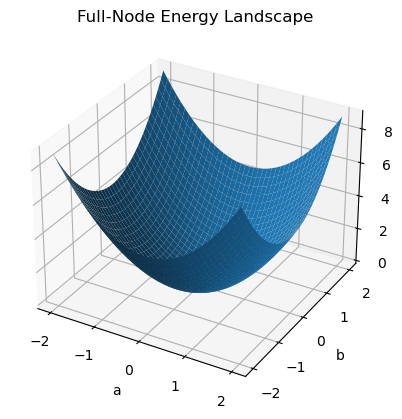

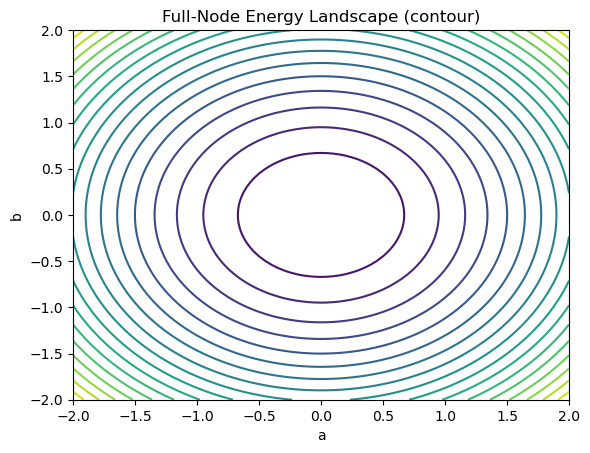

In [ ]:
def make_u(pairs):
    """
    pairs = [(uy0, uz0), (uy1, uz1), ...] for 8 nodes
    returns 16x1 displacement vector
    """
    flat = []
    for uy, uz in pairs:
        flat.extend([uy, uz])
    return sp.Matrix(flat)

def plot_energy_landscape_hamiltonian(H_func, q0, u_dir1, u_dir2,
                                      a_min=-2, a_max=2,
                                      b_min=-2, b_max=2,
                                      n=81,
                                      title="Hamiltonian Landscape"):
    """
    Plot H(a,b) = H_func(q(a,b))
    where q(a,b) = q0 + a*u_dir1 + b*u_dir2

    Parameters
    ----------
    H_func : callable
        Function H_func(q_vec) -> scalar
    q0 : array-like
        Reference configuration
    u_dir1, u_dir2 : array-like
        Two directions in configuration space
    """

    q0 = np.array(q0, dtype=float).reshape(-1)
    d1 = np.array(u_dir1, dtype=float).reshape(-1)
    d2 = np.array(u_dir2, dtype=float).reshape(-1)

    a_vals = np.linspace(a_min, a_max, n)
    b_vals = np.linspace(b_min, b_max, n)

    A, B = np.meshgrid(a_vals, b_vals)
    E = np.zeros_like(A, dtype=float)

    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            q_ab = q0 + A[i, j] * d1 + B[i, j] * d2
            E[i, j] = H_func(q_ab)

    min_idx = np.unravel_index(np.argmin(E), E.shape)
    print("Sampled-grid minimum:")
    print("a_min =", A[min_idx])
    print("b_min =", B[min_idx])
    print("H_min =", E[min_idx])

    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(A, B, E)
    ax.set_xlabel("a")
    ax.set_ylabel("b")
    ax.set_zlabel("H")
    ax.set_title(title)
    plt.show()

    plt.figure()
    plt.contour(A, B, E, levels=20)
    plt.xlabel("a")
    plt.ylabel("b")
    plt.title(title + " (contour)")
    plt.show()

# move top node of unit 0 up
u_dir1 = make_u([
    (0, 0),   # node 0
    (0, 0),   # node 1
    (0, 0),   # node 2
    (0, 1),   # node 3
    (0, 0),   # node 4
    (0, 0),   # node 5
    (0, 0),   # node 6
    (0, 0),   # node 7
])

# move top node of unit 1 up
u_dir2 = make_u([
    (0, 0),   # node 0
    (0, 0),   # node 1
    (0, 0),   # node 2
    (0, 0),   # node 3
    (0, 0),   # node 4
    (0, 0),   # node 5
    (0, 0),   # node 6
    (0, 1),   # node 7
])

plot_energy_landscape_hamiltonian(Hess, u_dir1, u_dir2, title="Full-Node Energy Landscape")